In [ ]:
#!python calc_scores.py -input ../datasets/xenium.zarr -normalize -moranI -gearyC -centrality_scores -co_occurrence -nhood_enrichment -output output_xenium_norm.h5ad
# killed after 229 minutes --> 3h 49min
#!python calc_scores.py -input ../datasets/xenium.zarr -normalize -moranI -gearyC -centrality_scores -nhood_enrichment -output output_xenium_norm.h5ad
# killed after 94 minutes --> 1h 34min
#!python -u calc_scores.py -input ../datasets/xenium.zarr -normalize -moranI -gearyC -centrality_scores -output output_xenium_norm.h5ad
# 3,5 min

In [ ]:
#!python calc_scores.py -input ../datasets/GSM6592055_M8.h5ad -filter -normalize -moranI -output ../outputs/GSM8_moranI_default.h5ad
# 43.2.0s
#!python calc_scores.py -input ../datasets/GSM6592055_M8.h5ad -filter -normalize -moranI -n_perms 10 -output ../outputs/GSM8_moranI_perms10.h5ad
# killed after 1h
#!python calc_scores.py -input ../datasets/GSM6592055_M8.h5ad -filter -normalize -moranI -n_perms 2 -output ../outputs/GSM8_moranI_perms2.h5ad
# killed after 50 min
#!python calc_scores.py -input ../datasets/GSM6592055_M8.h5ad -filter -normalize -moranI -n_perms 1 -output ../outputs/GSM8_moranI_perms1.h5ad
# killed after 35 min

# Testing the runtime of different scores with different settings

## Moran's I & Geary's C

squidpy.gr.spatial_autocorr(adata, ...)
[constant]
- mode='moran'               --> "moran", "geary"
- seed=None                  --> For reproducibility set seed=0 (especially useful when n_perms is set)

[user-configurable]
- n_perms=None               --> More permutations = more accurate p-values, but slower; Typical values: 100, 1000.
- corr_method='fdr_bh'
- n_jobs=None                --> None uses all available cores.

[maybe]
- two_tailed=False


## Centrality scores

squidpy.gr.centrality_scores(adata, ...)
[constant]
- cluster_key
- score=None              --> None, use all the options (closeness_centrality, average_clustering, degree_centrality) 

[user-configurable]
- n_jobs=None

## Neighborhood enrichment

squidpy.gr.nhood_enrichment(adata, ...)
[constant]
- cluster_key
- seed=None         --> For reproducibility set seed=0 (especially useful when n_perms is set)

[user-configurable]
- n_perms=1000 
- n_jobs=None
- numba_parallel=False

# Co-occurrence

squidpy.gr.co_occurrence(adata, ...)

[constant]
- cluster_key

[user-configurable]
- n_splits=None, 
- n_jobs=None
- interval=50

In [ ]:

import winsound
winsound.MessageBeep()

^C


python calc_scores.py -input ../datasets/GSM6592055_M8.h5ad -output ../outputs/GSM
8_default.h5ad -filter -normalize -centrality_scores -nhood_enrichment -co_occurrenc
e -moranI -gearyC


In [43]:
import scanpy as sc
import pandas as pd
adata = sc.read_h5ad("../outputs/GSM8_perms10.h5ad")
adata.X.shape
adata.var.shape

(19122, 9)

In [44]:

adata.uns['moranI'].head()
#adata.uns['gearyC'].shape
#adata.uns['leiden_centrality_scores'].head()
#adata.uns['leiden_nhood_enrichment'].keys()
# count: 10x10 array, zscore: 10x10 array
#adata.uns['leiden_co_occurrence'].keys()
# interval: 50x1 , occ: 10x10x49

#len(set(adata.obs["leiden"]))

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
ENSG00000211592,0.342351,0.0,0.000067,0.0,0.090909,0.000060,0.0,0.0,0.409702
ENSG00000211896,0.316822,0.0,0.000067,0.0,0.090909,0.000021,0.0,0.0,0.409702
ENSG00000211897,0.307965,0.0,0.000067,0.0,0.090909,0.000109,0.0,0.0,0.409702
ENSG00000198804,0.266989,0.0,0.000067,0.0,0.090909,0.000044,0.0,0.0,0.409702
ENSG00000211895,0.245759,0.0,0.000067,0.0,0.090909,0.000096,0.0,0.0,0.409702


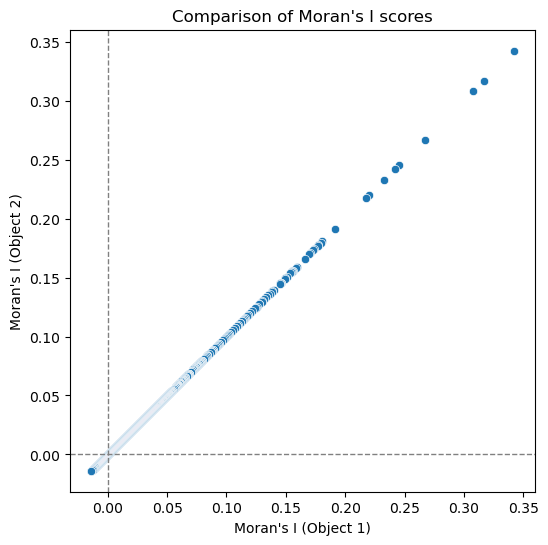

In [39]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your AnnData objects
adata1 = sc.read_h5ad("../outputs/GSM8_perms100.h5ad")
adata2 = sc.read_h5ad("../outputs/GSM8_perms10.h5ad")

# Extract Moran's I scores (assuming default key)
moran1 = adata1.uns["moranI"][["I"]].rename(columns={"I": "MoranI_1"})
moran2 = adata2.uns["moranI"][["I"]].rename(columns={"I": "MoranI_2"})

# Merge on gene names (index)
df = moran1.join(moran2, how="inner")

# Plot
plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x="MoranI_1", y="MoranI_2")
plt.xlabel("Moran's I (Object 1)")
plt.ylabel("Moran's I (Object 2)")
plt.title("Comparison of Moran's I scores")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.show()